In [1]:
import pandas as pd

df_rpk = pd.read_csv('All_source_plates_mapped_rpk_column_names_standardized_unique_identifiers_for_duplicates_with_hbdb_plate_samples_dropped_less_100k_readcounts_071426.csv').set_index('peptide')

In [20]:
import re

rpk_avg_hbdb = pd.read_csv('hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')

rpk_avg_sl = pd.read_csv('earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')

gfap = df_rpk.filter(regex='mAb')

In [26]:
peps_metadata = pd.read_csv('../../lassa_library_sequences_species_standardized_070726.csv').set_index('seq_id')

In [32]:
peps_metadata_gfap = peps_metadata.loc[peps_metadata['species'] == 'Homo sapiens']

In [ ]:
hbdb_gfap = rpk_avg_hbdb.loc[peps_metadata_gfap.index]

sl_gfap = rpk_avg_sl.loc[peps_metadata_gfap.index]

gfap_gfap = gfap.loc[peps_metadata_gfap.index]

In [39]:
hbdb_gfap_sum = hbdb_gfap.sum(axis=0)

sl_gfap_sum = sl_gfap.sum(axis=0)

gfap_gfap_sum = gfap_gfap.sum(axis=0)

In [ ]:
gfap_sum_all = pd.concat([sl_gfap_sum, hbdb_gfap_sum, gfap_gfap_sum], axis=0) #stack vertically

df_gfap_sum_all = pd.DataFrame(gfap_sum_all).reset_index()

In [64]:
df_gfap_sum_all = df_gfap_sum_all.rename(columns={'index': 'sample_ID', 0: 'RPK'})

In [73]:
df_gfap_sum_all['category'] = 'GFAP'

df_gfap_sum_all.loc[df_gfap_sum_all['sample_ID'].isin(sl_gfap.columns.to_list()), 'category'] = 'SL'

df_gfap_sum_all.loc[df_gfap_sum_all['sample_ID'].isin(hbdb_gfap.columns.to_list()), 'category'] = 'HBDB'

In [74]:
df_gfap_sum_all

,sample_ID,RPK,category
0,C-109-3_4_E7,4.992171,SL
1,C-111-3_3_I6,10.468949,SL
2,C-112-1_3_B3,12.841055,SL
3,C-130-2_3_C3,9.280485,SL
4,C-135-2_1_D2,6.775545,SL
...,...,...,...
511,mAb_2_6,54745.208638,GFAP
512,mAb_1_7,36220.870238,GFAP
513,mAb_1_8,38609.357091,GFAP
514,mAb_2_7,40804.657189,GFAP


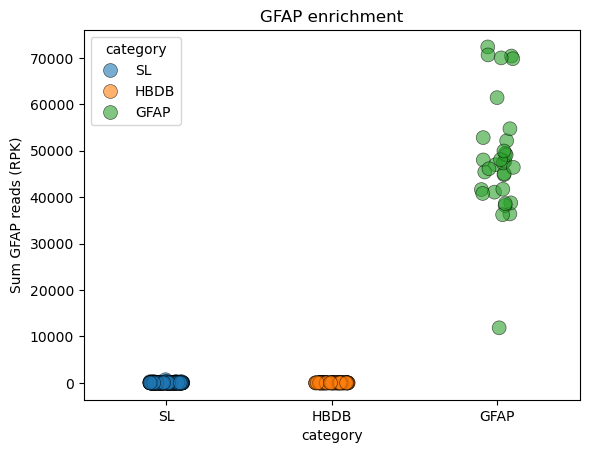

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns


#sns.boxplot(data=df_gfap_sum_all, x='category', y='RPK', hue='category')

sns.stripplot(
    data = df_gfap_sum_all, 
    x='category', 
    y='RPK', 
    hue='category', 
    size=10,
    dodge=False, 
    color=None,
    alpha=0.6, 
    legend=True, 
    edgecolor='black', 
    linewidth=0.5

)

plt.ylabel('Sum GFAP reads (RPK)')
plt.title('GFAP enrichment')
plt.show()